# Formalization 3 — Neural Measure-Valued Sequence Model

This notebook makes the hierarchy directly trainable.

The model receives a sequence of market observations and outputs a probability
measure over hierarchy atoms.

In simple terms:

\[
x_{1:t} \mapsto p_t \in \Delta^K
\]

where \(K\) is the number of hierarchy atoms.

## Mathematical object

Let \(A_1,\ldots,A_K\) be hierarchy atoms.

The model maps a time window into a simplex-valued vector:

\[
f_\theta(x_{t-w+1:t}) =
(p_{t,1},\ldots,p_{t,K})
\]

with

\[
p_{t,k}\ge 0,\qquad \sum_{k=1}^{K}p_{t,k}=1
\]

The vector can be interpreted as a learned hierarchical psychological measure.

A supervised version trains this measure to predict future movement:

\[
y_t = \mathbf{1}\{r_{t+h}>0\}
\]

An interpretable auxiliary head can also reconstruct greed/fear indices.

In [1]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch is not available in this environment:", repr(e))

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

In [2]:
def make_synthetic_market_data(n_steps: int = 2500, seed: int = 42) -> pd.DataFrame:
    """
    Synthetic market-like data with latent psychological regimes.

    Regimes:
    0 = calm accumulation
    1 = greedy trend
    2 = fear selloff
    3 = noisy transition

    This is not meant to simulate real markets faithfully.
    It exists so the hierarchy code can run without external data.
    Replace this function with a real OHLCV loader when you have data.
    """
    rng = np.random.default_rng(seed)

    transition = np.array([
        [0.965, 0.020, 0.005, 0.010],
        [0.025, 0.940, 0.015, 0.020],
        [0.025, 0.020, 0.935, 0.020],
        [0.250, 0.250, 0.250, 0.250],
    ])

    drift = np.array([0.00015, 0.00125, -0.00155, 0.00000])
    vol = np.array([0.006, 0.010, 0.017, 0.012])
    volume_mu = np.array([0.0, 0.45, 0.75, 0.25])
    volume_sigma = np.array([0.25, 0.35, 0.45, 0.40])

    regimes = np.zeros(n_steps, dtype=int)
    returns = np.zeros(n_steps)
    volume_z = np.zeros(n_steps)

    regimes[0] = 0
    for t in range(1, n_steps):
        regimes[t] = rng.choice(4, p=transition[regimes[t - 1]])
        r = drift[regimes[t]] + vol[regimes[t]] * rng.standard_normal()

        # Occasional regime-specific impulse.
        if regimes[t] == 1 and rng.random() < 0.020:
            r += abs(rng.normal(0.018, 0.007))
        if regimes[t] == 2 and rng.random() < 0.030:
            r -= abs(rng.normal(0.026, 0.010))

        returns[t] = r
        volume_z[t] = rng.normal(volume_mu[regimes[t]], volume_sigma[regimes[t]])

    price = 100.0 * np.exp(np.cumsum(returns))
    volume = np.exp(volume_z) * 1_000_000

    df = pd.DataFrame({
        "t": np.arange(n_steps),
        "close": price,
        "return": returns,
        "volume": volume,
        "latent_regime": regimes,
    })

    df["future_return_5"] = df["close"].shift(-5) / df["close"] - 1.0
    df["target_up_5"] = (df["future_return_5"] > 0).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df

df = make_synthetic_market_data()
df.head()

,t,close,return,volume,latent_regime,future_return_5,target_up_5
0,0,100.000000,0.000000,1.000000e+06,0,-0.007029,0
1,1,99.392860,-0.006090,1.206366e+06,0,0.001400,1
2,2,98.250867,-0.011556,7.221338e+05,0,0.012888,1
3,3,98.079327,-0.001747,9.958085e+05,0,0.022283,1
4,4,98.612991,0.005426,1.214640e+06,0,0.014757,1


In [3]:
def rolling_zscore(x: pd.Series, window: int, eps: float = 1e-8) -> pd.Series:
    mean = x.rolling(window, min_periods=window // 2).mean()
    std = x.rolling(window, min_periods=window // 2).std()
    return (x - mean) / (std + eps)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["ret_1"] = out["close"].pct_change().fillna(0.0)
    out["ret_5"] = out["close"].pct_change(5).fillna(0.0)
    out["ret_20"] = out["close"].pct_change(20).fillna(0.0)
    out["vol_10"] = out["ret_1"].rolling(10, min_periods=5).std().fillna(0.0)
    out["vol_30"] = out["ret_1"].rolling(30, min_periods=10).std().fillna(0.0)
    out["volume_z_20"] = rolling_zscore(np.log(out["volume"]), 20).fillna(0.0)
    out["drawdown_30"] = out["close"] / out["close"].rolling(30, min_periods=10).max() - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_5"], 30).fillna(0.0)
    out["fear_pressure"] = (-3.0 * out["drawdown_30"] + 2.0 * out["vol_10"] + 0.40 * out["volume_z_20"])
    out["greed_pressure"] = (2.5 * out["ret_20"] + 1.0 * out["trend_pressure"] + 0.25 * out["volume_z_20"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    return out.fillna(0.0)

features_df = make_market_features(df)
features_df[["t", "close", "ret_5", "ret_20", "vol_10", "volume_z_20", "fear_index", "greed_index", "target_up_5"]].head()

,t,close,ret_5,ret_20,vol_10,volume_z_20,fear_index,greed_index,target_up_5
0,0,100.000000,0.0,0.0,0.000000,0.0,0.0,0.5,0
1,1,99.392860,0.0,0.0,0.000000,0.0,0.0,0.5,1
2,2,98.250867,0.0,0.0,0.000000,0.0,0.0,0.5,1
3,3,98.079327,0.0,0.0,0.000000,0.0,0.0,0.5,1
4,4,98.612991,0.0,0.0,0.006385,0.0,0.0,0.5,1


## Prepare sequences

We use a sliding window of historical observations.

In [4]:
if not TORCH_AVAILABLE:
    raise RuntimeError("This training section requires PyTorch.")

sequence_features = [
    "ret_1", "ret_5", "ret_20", "vol_10", "vol_30",
    "volume_z_20", "drawdown_30", "greed_index", "fear_index",
]

class SequenceMarketDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, feature_columns: List[str], window: int = 32):
        self.window = window
        self.x_raw = frame[feature_columns].astype("float32").to_numpy()
        self.y = frame["target_up_5"].astype("int64").to_numpy()
        self.gf = frame[["greed_index", "fear_index"]].astype("float32").to_numpy()

        self.valid_indices = np.arange(window - 1, len(frame))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        end = self.valid_indices[idx]
        start = end - self.window + 1
        x = self.x_raw[start:end + 1]
        y = self.y[end]
        gf = self.gf[end]
        return torch.tensor(x), torch.tensor(y), torch.tensor(gf)

def time_split_frame(frame: pd.DataFrame, train_frac: float = 0.70, val_frac: float = 0.15):
    n = len(frame)
    a = int(n * train_frac)
    b = int(n * (train_frac + val_frac))
    return frame.iloc[:a].copy(), frame.iloc[a:b].copy(), frame.iloc[b:].copy()

train_frame, val_frame, test_frame = time_split_frame(features_df)
window = 32

train_ds = SequenceMarketDataset(train_frame, sequence_features, window=window)
val_ds = SequenceMarketDataset(val_frame, sequence_features, window=window)
test_ds = SequenceMarketDataset(test_frame, sequence_features, window=window)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

## Trainable measure-valued model

The model has three outputs:

1. `atom_logits`: probability distribution over hierarchy atoms;
2. `movement_logits`: future up/down prediction;
3. `gf_reconstruction`: reconstructed greed/fear indices.

The hierarchy atoms are learned latent states.

In [5]:
class NeuralMeasureSequenceModel(nn.Module):
    def __init__(self, n_features: int, n_atoms: int = 12, hidden: int = 96):
        super().__init__()
        self.encoder = nn.GRU(
            input_size=n_features,
            hidden_size=hidden,
            batch_first=True,
            num_layers=1,
        )
        self.atom_head = nn.Linear(hidden, n_atoms)
        self.prediction_head = nn.Sequential(
            nn.Linear(hidden + n_atoms, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
        )
        self.gf_head = nn.Sequential(
            nn.Linear(hidden + n_atoms, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        _, h = self.encoder(x)
        h = h[-1]
        atom_logits = self.atom_head(h)
        atom_probs = torch.softmax(atom_logits, dim=-1)
        combined = torch.cat([h, atom_probs], dim=-1)
        movement_logits = self.prediction_head(combined)
        gf_reconstruction = self.gf_head(combined)
        return atom_logits, atom_probs, movement_logits, gf_reconstruction

def entropy_regularizer(probs: torch.Tensor, target_entropy: float = 1.60) -> torch.Tensor:
    entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
    return (entropy - target_entropy) ** 2

model = NeuralMeasureSequenceModel(n_features=len(sequence_features), n_atoms=12)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = []
for epoch in range(1, 41):
    model.train()
    train_loss = 0.0

    for xb, yb, gf in train_loader:
        optimizer.zero_grad()
        atom_logits, atom_probs, movement_logits, gf_rec = model(xb)

        cls_loss = F.cross_entropy(movement_logits, yb)
        gf_loss = F.mse_loss(gf_rec, gf)
        entropy_loss = entropy_regularizer(atom_probs)

        loss = cls_loss + 0.25 * gf_loss + 0.02 * entropy_loss
        loss.backward()
        optimizer.step()
        train_loss += float(loss.item()) * len(xb)

    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    atom_usage = []

    with torch.no_grad():
        for xb, yb, gf in val_loader:
            atom_logits, atom_probs, movement_logits, gf_rec = model(xb)
            cls_loss = F.cross_entropy(movement_logits, yb)
            gf_loss = F.mse_loss(gf_rec, gf)
            entropy_loss = entropy_regularizer(atom_probs)
            loss = cls_loss + 0.25 * gf_loss + 0.02 * entropy_loss

            val_loss += float(loss.item()) * len(xb)
            pred = movement_logits.argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += len(xb)
            atom_usage.append(atom_probs.mean(dim=0).cpu().numpy())

    mean_atom_usage = np.mean(np.vstack(atom_usage), axis=0)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss / len(train_ds),
        "val_loss": val_loss / len(val_ds),
        "val_accuracy": correct / max(total, 1),
        "effective_atoms": float(np.exp(-(mean_atom_usage * np.log(mean_atom_usage + 1e-8)).sum())),
    })

measure_history = pd.DataFrame(history)
measure_history.tail()

,epoch,train_loss,val_loss,val_accuracy,effective_atoms
35,36,0.501034,0.965726,0.530612,7.548213
36,37,0.496901,1.025716,0.504373,7.943637
37,38,0.476598,1.019224,0.518950,7.711621
38,39,0.456895,1.183881,0.516035,7.996457
39,40,0.463054,1.102349,0.542274,8.259068


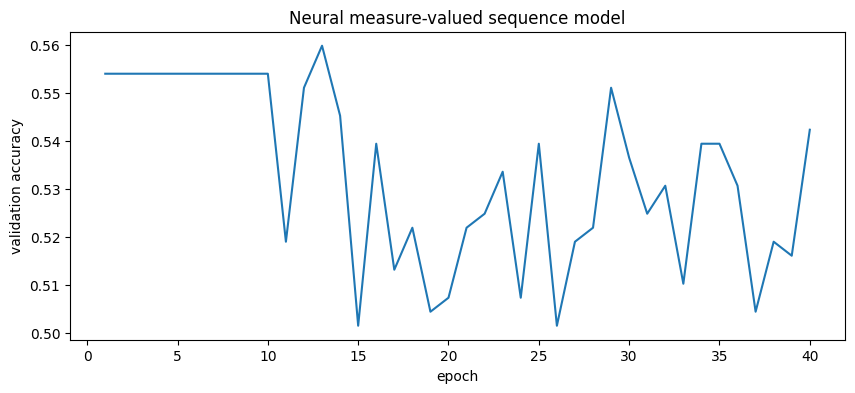

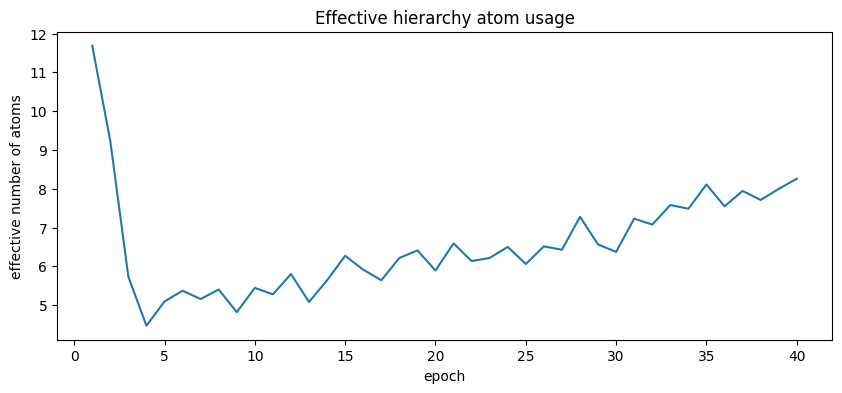

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(measure_history["epoch"], measure_history["val_accuracy"])
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Neural measure-valued sequence model")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(measure_history["epoch"], measure_history["effective_atoms"])
plt.xlabel("epoch")
plt.ylabel("effective number of atoms")
plt.title("Effective hierarchy atom usage")
plt.show()

## Inspect learned measure atoms

We extract average atom probabilities and relate them to greed/fear levels.

In [7]:
def collect_atom_table(model, dataset, batch_size=256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    rows = []
    model.eval()
    with torch.no_grad():
        for xb, yb, gf in loader:
            atom_logits, atom_probs, movement_logits, gf_rec = model(xb)
            pred_prob_up = torch.softmax(movement_logits, dim=-1)[:, 1]
            dominant_atom = atom_probs.argmax(dim=1)
            for i in range(len(xb)):
                rows.append({
                    "dominant_atom": int(dominant_atom[i].item()),
                    "prob_up": float(pred_prob_up[i].item()),
                    "true_up": int(yb[i].item()),
                    "greed": float(gf[i, 0].item()),
                    "fear": float(gf[i, 1].item()),
                })
    return pd.DataFrame(rows)

atom_table = collect_atom_table(model, val_ds)

atom_summary = atom_table.groupby("dominant_atom").agg(
    count=("dominant_atom", "size"),
    mean_prob_up=("prob_up", "mean"),
    observed_up_rate=("true_up", "mean"),
    mean_greed=("greed", "mean"),
    mean_fear=("fear", "mean"),
).reset_index()

atom_summary.sort_values("count", ascending=False)

,dominant_atom,count,mean_prob_up,observed_up_rate,mean_greed,mean_fear
4,6,135,0.535116,0.503704,0.535139,0.591269
0,1,131,0.619285,0.595420,0.489215,0.481489
1,3,44,0.635805,0.545455,0.470725,0.601748
5,9,18,0.026767,0.500000,0.437842,0.540835
3,5,11,0.677050,0.727273,0.336364,0.507692
2,4,2,0.491675,1.000000,0.840242,0.631506
6,11,2,0.816851,0.500000,0.530369,0.373703


## Interpretation protocol

This formalization is the closest to a modern trainable AI model.

It becomes scientifically interesting if:

- learned atoms specialize into distinct greed/fear/transition states;
- atom distributions are stable across time splits;
- the measure vector improves prediction beyond a plain GRU;
- atoms can be inspected instead of remaining pure black-box activations.

The key object is not "one feature."
It is a learned probability measure over latent hierarchy atoms.